In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def my_least_squares(X, Y):
    n = len(X)

    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_x2 = np.sum(X * X)
    sum_xy = np.sum(X * Y)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y - m * sum_x) / n

    return m, b

In [3]:
X_rand = np.random.rand(20)
Y_rand = np.random.rand(20)

idx = np.argsort(X_rand)
X_rand = X_rand[idx]
Y_rand = Y_rand[idx]

m_my, b_my = my_least_squares(X_rand, Y_rand)

A = np.vstack([X_rand, np.ones(len(X_rand))]).T
m_np, b_np = np.linalg.lstsq(A, Y_rand, rcond=None)[0]

print("Random test:")
print("My Least Squares: m =", m_my, " b =", b_my)
print("NumPy Least Squares: m =", m_np, " b =", b_np)

Random test:
My Least Squares: m = 0.35646195205973574  b = 0.36129390834789593
NumPy Least Squares: m = 0.35646195205973585  b = 0.3612939083478956


In [4]:
m_true = 2.5
b_true = -0.5

X = np.arange(0, 1.01, 0.01)

noise = np.random.rand(len(X))
sign = np.random.choice([-1, 1], len(X))

Y = m_true * X + b_true + sign * noise

m_my, b_my = my_least_squares(X, Y)

A = np.vstack([X, np.ones(len(X))]).T
m_np, b_np = np.linalg.lstsq(A, Y, rcond=None)[0]

print("True line: m =", m_true, " b =", b_true)
print("My Least Squares: m =", m_my, " b =", b_my)
print("NumPy Least Squares: m =", m_np, " b =", b_np)

True line: m = 2.5  b = -0.5
My Least Squares: m = 2.410486527971656  b = -0.47640262456839577
NumPy Least Squares: m = 2.4104865279716563  b = -0.4764026245683964


In [5]:
Y_pred = m_my * X + b_my

residuals = Y - Y_pred
abs_residuals = np.abs(residuals)

max_i = np.argmax(abs_residuals)
min_i = np.argmin(abs_residuals)

print("Largest residual at X =", X[max_i], " value =", residuals[max_i])
print("Smallest residual at X =", X[min_i], " value =", residuals[min_i])

Largest residual at X = 0.6  value = 0.9950554910118131
Smallest residual at X = 0.43  value = -0.011575932176100201


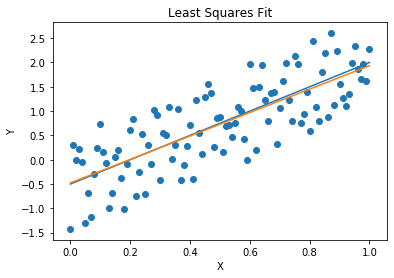

In [6]:
Y_pred = m_my * X + b_my
Y_true = m_true * X + b_true

plt.scatter(X, Y)
plt.plot(X, Y_true)
plt.plot(X, Y_pred)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Fit")
plt.show()

The custom least squares gave pretty much the same slope and intercept as the Numpy least squares function, which shows that the manual implementation is correct. Since random noise was added to the data, the fitted line is close ot the original but not exactly the same. The residuals show which points deviate the most and least from the predicted line.